---Mangesh S Rajguru From TE 39---


Experiment 6 : Data Analytics III<br>
DataSet      : Iris Dataset (from sklearn)<br>
Objective    : To Predict the species of flower with the help pf features like sepal and petal's width and length

In [21]:
# Explaination And Illustration :
# In this Experiment We provided the Iris dataset to the Naive Bayes Model
# then define feature and target,perform 80% training and 20% testing , then train the model, followed by making predictions and
# evaluating the model and  finally plotting the graph showing the diffrence between the actual and predicted prices

In [5]:
# Steps :1) Import Libraries 
#        2) craete your own dataset
#        3) Define Features and Target 
#           Where we put features on the X axis and target on the Y axis as price
#        4) Split into train and test
#           Where we train the model 80% and test it on 20%
#        5) Train the model
#           Here, we provide the dataset to the empty model and start the training
#        6) Make Predictions
#           Here, we gave the model x values and got y values
#        7) find the confudion matrix
#           where TP,TN,FP,FN means
#        8) Plot Actual Vs Predicted

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [8]:
# STEP 1: Load Iris Dataset
iris = sns.load_dataset('iris')
print("Iris Dataset Loaded!")
print(f"Shape: {iris.shape}")
print("\nFirst 5 rows:")
print(iris.head())

print("\nSpecies in dataset:")
print(iris['species'].value_counts())

Iris Dataset Loaded!
Shape: (150, 5)

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Species in dataset:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [10]:
# STEP 2: Define Features and Target
X = iris.drop('species', axis=1)  # 4 features
y = iris['species']                # target

print(f"\nFeatures: {list(X.columns)}")
print(f"Target: species")


Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Target: species


In [11]:
# STEP 3: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")


Training samples: 120
Testing samples: 30


In [13]:
# STEP 4: Train Naive Bayes Model
model = GaussianNB()
model.fit(X_train, y_train)
print("\n Naive Bayes Model Trained!")



 Naive Bayes Model Trained!


In [14]:
# STEP 5: Predictions
y_pred = model.predict(X_test)
print("\nPredicted values:")
print(y_pred)
print("\nActual values:")
print(list(y_test))


Predicted values:
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa']

Actual values:
['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor', 'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa', 'virginica', 'setosa', 'virginica', 'virginica', 'virginica', 'virginica', 'virginica', 'setosa', 'setosa']


In [16]:
# STEP 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n---Confusion Matrix---")
print(cm)


---Confusion Matrix---
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [18]:
# STEP 7: Performance Metrics
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

print("\n=== PERFORMANCE METRICS ===")
print(f"Accuracy   = {accuracy:.4f}")
print(f"Error Rate = {error:.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))


=== PERFORMANCE METRICS ===
Accuracy   = 1.0000
Error Rate = 0.0000

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [19]:
# Manual TP, FP, TN, FN for each class
print("=== TP, FP, TN, FN per class ===")
classes = model.classes_
for i, cls in enumerate(classes):
    TP = cm[i][i]
    FP = cm[:, i].sum() - TP
    FN = cm[i, :].sum() - TP
    TN = cm.sum() - TP - FP - FN
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    print(f"\nClass: {cls}")
    print(f"  TP={TP}, FP={FP}, TN={TN}, FN={FN}")
    print(f"  Precision={precision:.4f}, Recall={recall:.4f}")

=== TP, FP, TN, FN per class ===

Class: setosa
  TP=10, FP=0, TN=20, FN=0
  Precision=1.0000, Recall=1.0000

Class: versicolor
  TP=9, FP=0, TN=21, FN=0
  Precision=1.0000, Recall=1.0000

Class: virginica
  TP=11, FP=0, TN=19, FN=0
  Precision=1.0000, Recall=1.0000


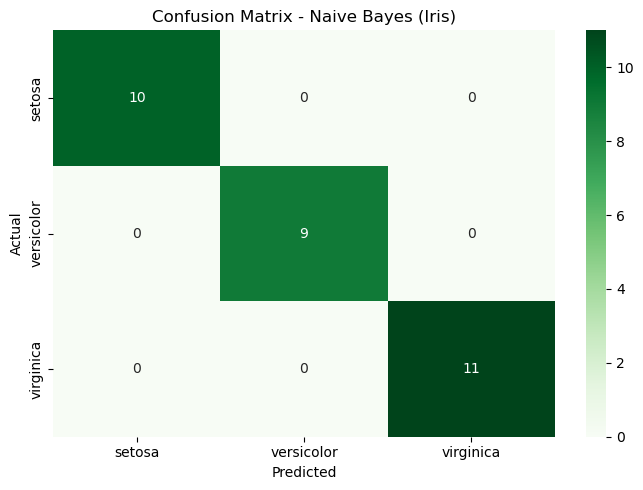

Plot saved!


In [20]:
# STEP 8: Plot Confusion Matrix
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes,
            yticklabels=classes)
plt.title('Confusion Matrix - Naive Bayes (Iris)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('exp6_naive_bayes.png')
plt.show()
print("Plot saved!")